In [ ]:
import sys
#!pip install keplergl --target ./my_custom_packages
sys.path.append('./my_custom_packages') 
# Polars, fastexcel, hvplot, "vegafusion[embed]>=1.5.0", ""vl-convert-python>=1.6.0"", xgboost, graphviz, geopandas, setuptools<81
# keplergl, 

import polars as pl
import pandas as pd
import polars.selectors as cs
import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import plotly.express as px

import geopandas as gpd
import plotly.graph_objects as go
from keplergl import KeplerGl
import shapely

from scipy.stats import chi2_contingency


 

/stor/home/he4249/orange/my_custom_packages/keplergl/keplergl.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


: 

In [2]:
df_merged = pl.read_parquet("df_merged.parquet")
display(df_merged.head())

msisdn,site_id,nb_jours,date,Gamme_groupe,Nom du forfait,CA,Group_canal,sig_region_name,sig_district_name,sig_commune_name,x,y,Max_RAT,Typologie,Typologie site,sig_nom_site,region_cleaned
str,str,i64,date,str,str,f64,str,str,str,str,f64,f64,str,str,str,str,str
"""261320236812""","""1450-16867""",31,2026-05-05,"""Akama/Be Connect""","""akama up""",500.0,"""IVR""","""Analamanga""","""Antananarivo renivohitra""","""Antananarivo""",47.56831,-18.919853,"""4G+_TDD""","""Urbain""","""Densification""","""TanaAmbolokandrina""","""Analamanga"""
"""261320274396""","""2600-6926083""",31,2026-05-25,"""Akama/Be Connect""","""akama plus""",1000.0,"""APP OM""","""Atsinanana""","""Toamasina I""","""CU Toamasina""",49.387249,-18.15592,"""4G+_FDD""","""Urbain""","""Densification""","""TamaTanambao""","""Atsinanana"""
"""261320251199""","""3400-39723""",21,2026-05-07,"""Be""","""be 2000 new""",2000.0,"""IVR""","""Diana""","""Ambanja""","""Ambohimena""",48.354942,-13.558111,"""4G_FDD""","""Rural""","""Backbone et Couverture""","""AmbanjaAnkify""","""Diana"""
"""261320248283""","""1641-4359425""",45,2026-05-26,"""Akama/Be Connect""","""akama full""",2000.0,"""IVR""","""Analamanga""","""Antananarivo renivohitra""","""Antananarivo""",47.53292,-18.920139,"""5G""","""Urbain""","""Backbone et Couverture""","""TanaAndafiavaratra""","""Analamanga"""
"""261320454752""","""1651-4396547""",30,2026-05-06,"""Akama/Be Connect""","""akama up""",500.0,"""USSD""","""Analamanga""","""Antananarivo Atsimondrano""","""Ampanefy""",47.50986,-18.977667,"""4G+_FDD""","""Peri-Urbain""","""Couverture""","""TanaBevalala""","""Analamanga"""


In [12]:
%%time

# Regression lineaire et anova

df_pd = df_merged.to_pandas()
display(sum(df_pd["Max_RAT"] == "2G"))
# Less than 1% of all entries

df_pd = df_pd[df_pd["Max_RAT"] != "2G"]

lm_r = ols("CA ~ nb_jours + C(Group_canal) + C(Max_RAT) + C(Typologie)", data = df_pd).fit()
display(lm_r.summary())

# CA in terms of Max_RAT
anova_max_rat = sm.stats.anova_lm(ols('CA ~ C(Max_RAT)', data = df_pd).fit(), typ = 2)
display(anova_max_rat)


32474

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     CA   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                 8.706e+04
Date:                Thu, 23 Jul 2026   Prob (F-statistic):               0.00
Time:                        07:30:49   Log-Likelihood:            -3.5082e+08
No. Observations:            37943670   AIC:                         7.016e+08
Df Residuals:                37943656   BIC:                         7.016e+08
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                1806.8339      2.968    608.689      0.000    1801.016    1812.652
C(Group_canal)[T.IVR]    -949.0324      2.308   -411.197      0.000    -953.556    -944.509
C(Group_canal)[T.MAXIT]    81.9747      4.215     19.447      0.000      73.713      90.236
C(Group_canal)[T.MBC]    8.015e+04     93.135    860.562      0.000       8e+04    8.03e+04
C(Group_canal)[T.USSD]   -692.4548      2.330   -297.204      0.000    -697.021    -687.888
C(Group_canal)[T.WEB]    -533.2019      2.879   -185.225      0.000    -538.844    -527.560
C(Max_RAT)[T.4G+_FDD]      77.4602      1.712     45.233      0.000      74.104      80.817
C(Max_RAT)[T.4G+_TDD]     135.5004      1.853     73.115      0.000     131.868     139.133
C(Max_RAT)[T.4G_FDD]       46.3039      1.392     33.264      0.000      43.576      49.032
C(Max_RAT)[T.4G_TDD]       13.3399      7.463      1.787      0.074      -1.288      27.968
C(Max_RAT)[T.5G]          186.0803      1.917     97.060      0.000     182.323     189.838
C(Typologie)[T.Rural]     -44.6397      1.635    -27.298      0.000     -47.845     -41.435
C(Typologie)[T.Urbain]    -83.1556      1.318    -63.075      0.000     -85.740     -80.572
nb_jours                   -1.5053      0.029    -52.064      0.000      -1.562      -1.449
==============================================================================
Omnibus:                122556289.832   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):   41876550963719.312
Skew:                          53.711   Prob(JB):                         0.00
Kurtosis:                    5148.491   Cond. No.                     7.87e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.87e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

,sum_sq,df,F,PR(>F)
C(Max_RAT),4.344783e+11,5.0,13448.79298,0.0
Residual,2.451625e+14,37943664.0,NaN,NaN


CPU times: user 10min 21s, sys: 5min 24s, total: 15min 45s
Wall time: 9min


In [14]:
%%time

# Regression lineaire et anova WITH CA LOG SCALE

df_pd["CA_log"] = np.log(df_pd["CA"] + 1)


lm_r_log = ols("CA_log ~ nb_jours + C(Group_canal) + C(Max_RAT) + C(Typologie)", data = df_pd).fit()
display(lm_r_log.summary())

# CA in terms of Max_RAT
anova_max_rat_log = sm.stats.anova_lm(ols('CA_log ~ C(Max_RAT)', data = df_pd).fit(), typ = 2)
display(anova_max_rat_log)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 CA_log   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                 2.453e+04
Date:                Thu, 23 Jul 2026   Prob (F-statistic):               0.00
Time:                        07:42:36   Log-Likelihood:            -3.8465e+07
No. Observations:            37943670   AIC:                         7.693e+07
Df Residuals:                37943656   BIC:                         7.693e+07
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   6.7719      0.001   8576.789      0.000       6.770       6.773
C(Group_canal)[T.IVR]      -0.2730      0.001   -444.726      0.000      -0.274      -0.272
C(Group_canal)[T.MAXIT]    -0.0344      0.001    -30.694      0.000      -0.037      -0.032
C(Group_canal)[T.MBC]       4.3505      0.025    175.617      0.000       4.302       4.399
C(Group_canal)[T.USSD]     -0.2395      0.001   -386.480      0.000      -0.241      -0.238
C(Group_canal)[T.WEB]      -0.2825      0.001   -369.010      0.000      -0.284      -0.281
C(Max_RAT)[T.4G+_FDD]       0.0376      0.000     82.446      0.000       0.037       0.038
C(Max_RAT)[T.4G+_TDD]       0.0320      0.000     64.837      0.000       0.031       0.033
C(Max_RAT)[T.4G_FDD]        0.0199      0.000     53.867      0.000       0.019       0.021
C(Max_RAT)[T.4G_TDD]       -0.0246      0.002    -12.392      0.000      -0.028      -0.021
C(Max_RAT)[T.5G]            0.0513      0.001    100.540      0.000       0.050       0.052
C(Typologie)[T.Rural]       0.0658      0.000    151.353      0.000       0.065       0.067
C(Typologie)[T.Urbain]      0.0233      0.000     66.380      0.000       0.023       0.024
nb_jours                    0.0002   7.69e-06     25.363      0.000       0.000       0.000
==============================================================================
Omnibus:                  3943986.673   Durbin-Watson:                   1.990
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         31210801.038
Skew:                           0.166   Prob(JB):                         0.00
Kurtosis:                       7.431   Cond. No.                     7.87e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.87e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

,sum_sq,df,F,PR(>F)
C(Max_RAT),4.688579e+03,5.0,2091.787265,0.0
Residual,1.700956e+07,37943664.0,NaN,NaN


CPU times: user 10min 21s, sys: 5min 30s, total: 15min 51s
Wall time: 8min 59s


In [3]:
# Baseline
display(round(((2.71828)**6.7719 - 1.0), 2))

871.96

In [4]:
# PARETO check

df_ca = df_merged.group_by(["msisdn"]).agg(pl.col("CA").sum().alias("Sum_CA"))

df_pd_ca = df_ca.to_pandas()

vip_threshold = df_pd_ca["Sum_CA"].describe(percentiles=[0.5, 0.8, 0.9, 0.95, 0.99])

display(vip_threshold)


total_revenue = df_pd_ca["Sum_CA"].sum()

rev_top_20 = df_pd_ca[df_pd_ca["Sum_CA"] >= 8600]["Sum_CA"].sum()
print(f"Top 20% spenders: {(rev_top_20 / total_revenue) * 100:.1f}% of revenue")

rev_top_5 = df_pd_ca[df_pd_ca["Sum_CA"] >= 22100]["Sum_CA"].sum()
print(f"Top 5% spenders: {(rev_top_5 / total_revenue) * 100:.1f}% of revenue")


user_top_20 = df_pd_ca[df_pd_ca["Sum_CA"] >= 8600]["msisdn"].tolist()

print(f"Top 20% user: {(df_merged.filter(pl.col("msisdn").is_in(user_top_20)).shape[0] / df_merged.shape[0]) * 100:.1f}% of traffic")

user_top_5 = df_pd_ca[df_pd_ca["Sum_CA"] >= 22100]["msisdn"].tolist()

print(f"Top 5% user: {(df_merged.filter(pl.col("msisdn").is_in(user_top_5)).shape[0] / df_merged.shape[0]) * 100:.1f}% of traffic")

count    2.874492e+06
mean     1.294847e+04
std      2.643068e+04
min      0.000000e+00
50%      4.700000e+03
80%      1.745000e+04
90%      3.275000e+04
95%      5.200000e+04
99%      1.150000e+05
max      7.591700e+06
Name: Sum_CA, dtype: float64

Top 20% spenders: 85.3% of revenue
Top 5% spenders: 64.7% of revenue
Top 20% user: 78.6% of traffic
Top 5% user: 52.2% of traffic


In [5]:
# XGBOOST classifier prep

df_pd = df_merged.to_pandas()

df_pd_ca["VIP"] = (df_pd_ca["Sum_CA"] >= 8600).astype(int)

df_xgboost = df_pd.merge(df_pd_ca[["msisdn", "VIP"]], on = "msisdn")

y = df_xgboost["VIP"]

x = pd.get_dummies(df_xgboost[["nb_jours", "Group_canal", "Typologie", "Max_RAT"]], drop_first = False)


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 4, stratify = y)


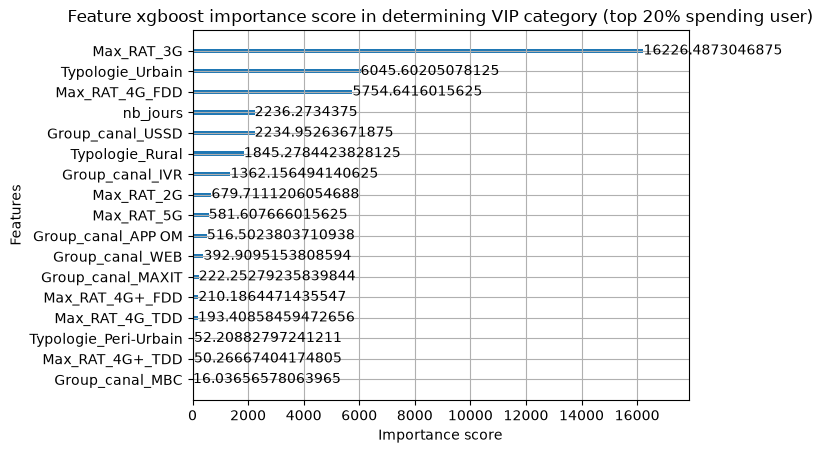

'              precision    recall  f1-score   support\n\n           0       0.62      0.12      0.20   1627296\n           1       0.80      0.98      0.88   5967949\n\n    accuracy                           0.80   7595245\n   macro avg       0.71      0.55      0.54   7595245\nweighted avg       0.76      0.80      0.74   7595245\n'

CPU times: user 38min 30s, sys: 15.4 s, total: 38min 46s
Wall time: 39.1 s


In [6]:
%%time

xgb_model = xgb.XGBClassifier(
    n_estimators = 150,
    max_depth = 6,
    learning_rate = 0.1,
    n_jobs = -1,
    tree_method = 'hist',
    random_state = 4 
)


xgb_model.fit(x_train, y_train)

# Gain measures the improvement in accuracy a feature brings to the branches it splits

xgb.plot_importance(xgb_model, importance_type = 'gain')
plt.title("Feature xgboost importance score in determining VIP category (top 20% spending user)")
plt.show()

y_predic = xgb_model.predict(x_test)
display(classification_report(y_test, y_predic))

In [7]:
print(classification_report(y_test, y_predic))

              precision    recall  f1-score   support

           0       0.62      0.12      0.20   1627296
           1       0.80      0.98      0.88   5967949

    accuracy                           0.80   7595245
   macro avg       0.71      0.55      0.54   7595245
weighted avg       0.76      0.80      0.74   7595245



In [ ]:
# Why are most big spenders using 3G networks?


# M2M (Machine-to-Machine)
# High volume transaction devices like  
# Point of Sale (POS)terminals, mobile money merchant phones, and older dual-SIM business phones
# default to 3G. They don't need 4G broadband speeds to send few kilobyte Orange Money transaction 

# Voice and USSD fallback
# Unless a user has a specific VoLTE (Voice over LTE) setup 
# making a phone call or dialing a USSD code forces the phone to temporarily drop from 4G down to 3G. 
# If VIPs are constantly making business calls and doing USSD transfers, 
# their network logs will have their most connected site to be 3G.

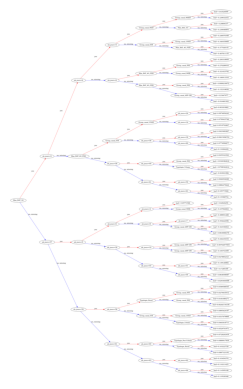

/stor/home/he4249/orange/my_custom_packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` instead. 
  warnings.warn(


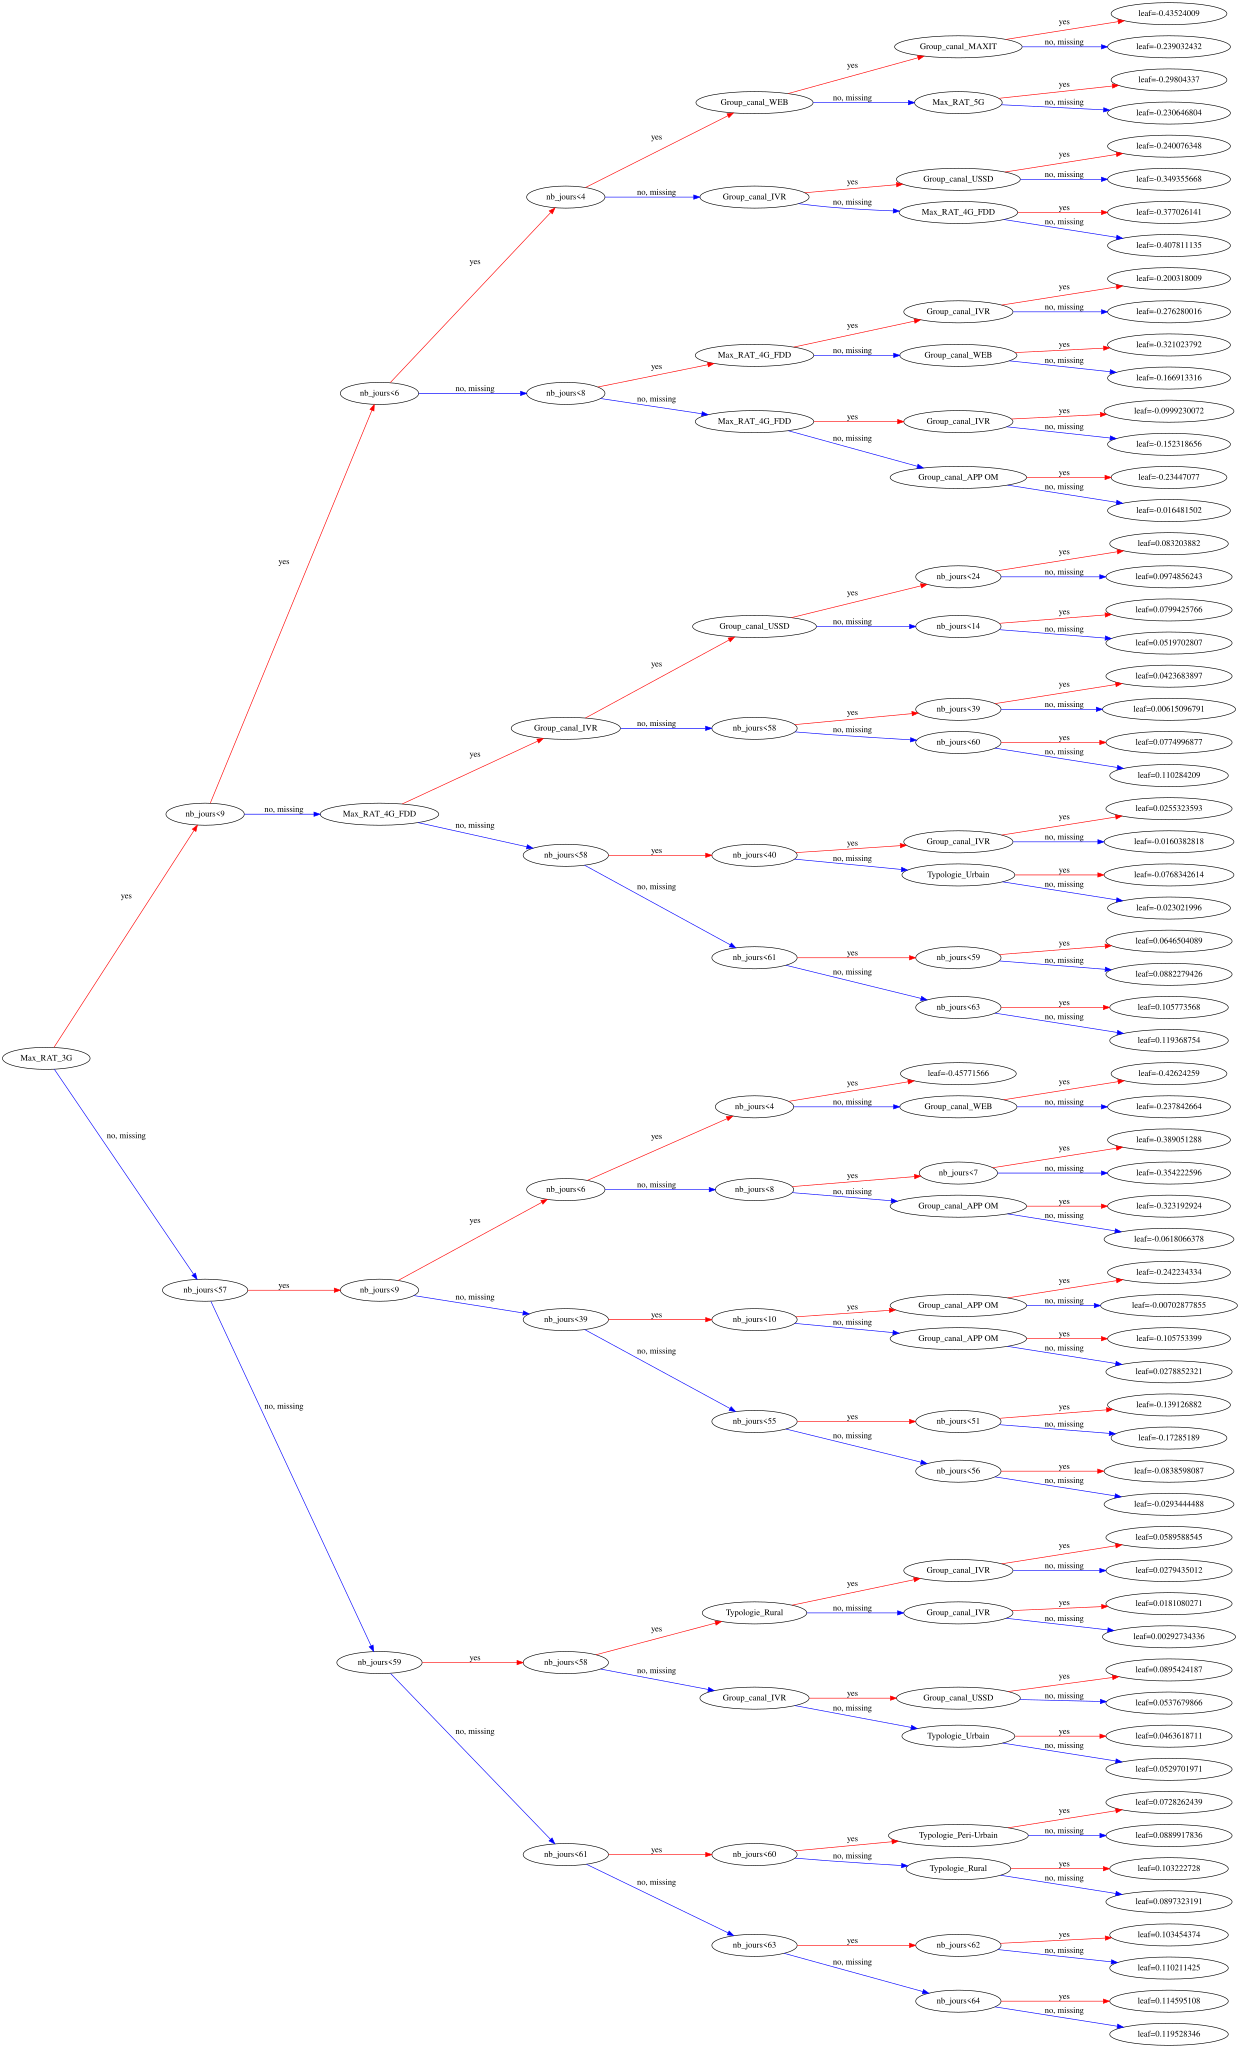

'0:[Max_RAT_3G] yes=1,no=2\n\t1:[nb_jours<9] yes=3,no=4,missing=4\n\t\t3:[nb_jours<6] yes=7,no=8,missing=8\n\t\t\t7:[nb_jours<4] yes=15,no=16,missing=16\n15:[Group_canal_WEB] yes=31,no=32\n31:[Group_canal_MAXIT] yes=63,no=64\n\t\t\t\t\t\t63:leaf=-0.43524009\n\t\t\t\t\t\t64:leaf=-0.239032432\n32:[Max_RAT_5G] yes=65,no=66\n\t\t\t\t\t\t65:leaf=-0.29804337\n\t\t\t\t\t\t66:leaf=-0.230646804\n16:[Group_canal_IVR] yes=33,no=34\n33:[Group_canal_USSD] yes=67,no=68\n\t\t\t\t\t\t67:leaf=-0.240076348\n\t\t\t\t\t\t68:leaf=-0.349355668\n34:[Max_RAT_4G_FDD] yes=69,no=70\n\t\t\t\t\t\t69:leaf=-0.377026141\n\t\t\t\t\t\t70:leaf=-0.407811135\n\t\t\t8:[nb_jours<8] yes=17,no=18,missing=18\n17:[Max_RAT_4G_FDD] yes=35,no=36\n35:[Group_canal_IVR] yes=71,no=72\n\t\t\t\t\t\t71:leaf=-0.200318009\n\t\t\t\t\t\t72:leaf=-0.276280016\n36:[Group_canal_WEB] yes=73,no=74\n\t\t\t\t\t\t73:leaf=-0.321023792\n\t\t\t\t\t\t74:leaf=-0.166913316\n18:[Max_RAT_4G_FDD] yes=37,no=38\n37:[Group_canal_IVR] yes=75,no=76\n\t\t\t\t\t\t75

In [ ]:

xgb.plot_tree(xgb_model, tree_idx = 0, rankdir = "LR")
plt.show()

tree_graph = xgb.to_graphviz(xgb_model, num_trees = 0, rankdir = "LR")
display(tree_graph)

tree_text = xgb_model.get_booster().get_dump()[0]
display(tree_text)

In [9]:
# Are vip more concentrated in frequent 3G cell users than in frequent 4G/5G users?

vip_table = df_xgboost.groupby(["Max_RAT", "Typologie"]).agg(
    Total_activity_rows = ("msisdn", "count"),
    Total_VIP_rows = ("VIP", "sum")
)

vip_table["VIP_concentration_%"] = (vip_table["Total_VIP_rows"] / vip_table["Total_activity_rows"]) * 100

# Sort by the highest concentration to see what floats to the top
vip_table = vip_table.sort_values("VIP_concentration_%", ascending=False)

# VIPs by data technology and geography
display(vip_table)

Total_activity_rows  Total_VIP_rows  VIP_concentration_%
Max_RAT Typologie                                                            
5G      Urbain                   4120840         3659476            88.804127
4G+_FDD Urbain                   8186617         7089222            86.595257
4G+_TDD Urbain                   4712097         4055146            86.058203
5G      Peri-Urbain               676735          579510            85.633224
4G+_TDD Peri-Urbain               924306          790804            85.556515
4G+_FDD Peri-Urbain               936567          797758            85.178957
        Rural                     279196          231784            83.018381
4G+_TDD Rural                      22213           18429            82.964930
4G_TDD  Urbain                     84498           69378            82.106085
4G_FDD  Urbain                   5039895         3993203            79.231869
        Peri-Urbain              1368214         1022248            74.714043
        Rural                    3670953         2661422            72.499484
4G_TDD  Peri-Urbain                33080           22469            67.923216
3G      Urbain                    344492          219934            63.842992
        Rural                    6928636         4245014            61.267672
        Peri-Urbain               615409          365430            59.380022
2G      Rural                      32474           18516            57.017922

In [10]:
# What canal are those users choosing?

urban_high_speed_df = df_xgboost[
    (df_xgboost["Max_RAT"].str.contains("4G|5G")) & 
    (df_xgboost["Typologie"].isin(["Urbain", "Peri-Urbain"]))
]

channel_check = urban_high_speed_df.groupby("Group_canal").agg(
    Total_activity_rows=("msisdn", "count"),
    Total_VIP_rows=("VIP", "sum")
)

channel_check["VIP_concentration_%"] = (channel_check["Total_VIP_rows"] / channel_check["Total_activity_rows"]) * 100

channel_check = channel_check.sort_values("VIP_concentration_%", ascending=False)

display(channel_check)

# Digital channels MAXIT + APP OM + WEB, VIP Rows: ~950,000
# Legacy channels USSD + IVR, VIP Rows: ~4,770,000
# Among the wealthiest highest speed urban users, 83% of their VIP activity is still happening on USSD and IVR.

,Total_activity_rows,Total_VIP_rows,VIP_concentration_%
Group_canal,,,
MBC,677,675,99.704579
MAXIT,456312,430847,94.419388
APP OM,1174253,1102681,93.904891
WEB,1767070,1638391,92.717946
USSD,9954192,8508884,85.480409
IVR,12730345,10397736,81.676781


In [ ]:
# Does better data technology trigger high value data package spending? 



product_determinants = pd.crosstab(
    index = df_xgboost["Max_RAT"],
    columns = df_xgboost["Gamme_groupe"],
    values = df_xgboost["CA"],
    aggfunc = ["count", "mean"]
)

display(product_determinants)

# Infrastructure upgrades do change what people buy
# Infrastructure change how much they consume

count  \
Gamme_groupe 24000ar ttc|24000ar ttc|24000ar incl. tax   
Max_RAT                                                  
2G                                                 NaN   
3G                                                 NaN   
4G+_FDD                                            0.0   
4G+_TDD                                            NaN   
4G_FDD                                             NaN   
4G_TDD                                             NaN   
5G                                                 NaN   

                                                                                      \
Gamme_groupe 25 sms vers tout operateur|25 sms vers tout operateur|25sms to national   
Max_RAT                                                                                
2G                                                          NaN                        
3G                                                          NaN                        
4G+_FDD                                                     NaN                        
4G+_TDD                                                     NaN                        
4G_FDD                                                      NaN                        
4G_TDD                                                      NaN                        
5G                                                          0.0                        

                                                                     \
Gamme_groupe 50 sms vers orange|50 sms vers orange|50sms to orange"   
Max_RAT                                                               
2G                                                          NaN       
3G                                                          NaN       
4G+_FDD                                                     NaN       
4G+_TDD                                                     0.0       
4G_FDD                                                      NaN       
4G_TDD                                                      NaN       
5G                                                          NaN       

                                                                               \
Gamme_groupe Akama/Be Connect         Be     Be Sms Data Other Divertissement   
Max_RAT                                                                         
2G                     1075.0    28902.0     2495.0        NaN            2.0   
3G                  1385087.0  5493932.0  1008451.0       59.0          741.0   
4G+_FDD             4355886.0  4369627.0   671672.0      484.0         3183.0   
4G+_TDD             3175959.0  2196817.0   279768.0      675.0         3570.0   
4G_FDD              3545540.0  5587280.0   942243.0      311.0         2516.0   
4G_TDD                69203.0    44201.0     4092.0        4.0           49.0   
5G                  2686291.0  1874370.0   231611.0      590.0         3284.0   

                                           ...  \
Gamme_groupe Freefiber-Home International  ...   
Max_RAT                                    ...   
2G                      NaN           NaN  ...   
3G                     32.0         224.0  ...   
4G+_FDD               419.0         902.0  ...   
4G+_TDD               764.0         809.0  ...   
4G_FDD                364.0         633.0  ...   
4G_TDD                 10.0          18.0  ...   
5G                    562.0         638.0  ...   

                                                                           \
Gamme_groupe voix tout operateur 1h|voix tout operateur 1h|1h to national   
Max_RAT                                                                     
2G                                                          NaN             
3G                                                          NaN             
4G+_FDD                                                     NaN             
4G+_TDD                                                     NaN             
4G_FDD                   

In [17]:
# Does site infrastructure explain customer stability and value?


site_strategy_analysis = df_xgboost.groupby(["Typologie site", "Typologie"]).agg(
    Avg_days_connected = ("nb_jours", "mean"),
    Avg_spend_per_row = ("CA", "mean"),
    Total_revenue = ("CA", "sum")
).sort_values(by = "Avg_spend_per_row", ascending = False)

display(site_strategy_analysis)

Avg_days_connected  Avg_spend_per_row  \
Typologie site         Typologie                                            
Densification          Peri-Urbain           28.353724        1239.957217   
Couverture             Peri-Urbain           31.504835        1038.645593   
Densification          Urbain                27.372446        1033.422138   
Couverture             Urbain                28.393220         999.878583   
Backbone et Couverture Urbain                28.592939         946.006314   
                       Peri-Urbain           35.386459         894.783830   
                       Rural                 38.573879         877.561793   
Densification          Rural                 33.707785         875.544218   
Couverture             Rural                 37.908669         849.172048   

                                    Total_revenue  
Typologie site         Typologie                   
Densification          Peri-Urbain   2.222958e+09  
Couverture             Peri-Urbain   2.473972e+09  
Densification          Urbain        1.283585e+10  
Couverture             Urbain        8.637782e+09  
Backbone et Couverture Urbain        1.351671e+09  
                       Peri-Urbain   3.396671e+08  
                       Rural         1.541707e+09  
Densification          Rural         8.005040e+08  
Couverture             Rural         7.016175e+09

In [ ]:
# Do geographic regions explain revenue density and channel preference?

regional_segmentation = df_xgboost.groupby("sig_region_name").agg(
    Total_transactions = ("msisdn", "count"),
    Total_CA = ("CA", "sum"),
    Preferred_channel = ("Group_canal", lambda x: x.value_counts().index[0]),
    Most_used_forfait = ("Nom du forfait", lambda x: x.value_counts().index[0])
).sort_values(by = "Total_CA", ascending=False)

display(regional_segmentation)


# Analamanga: Prefers USSD and buys "Akama Plus" Data centric

# (Diana not anymore), Sava, Boeny (Coastal): Rely on IVR and buy "Be 500 New" voice.

# IVR dominates throughout

,Total_transactions,Total_CA,Preferred_channel,Most_used_forfait
sig_region_name,,,,
Diana,10033174,9.708940e+09,IVR,akama plus
Analamanga,5838862,7.557065e+09,USSD,akama plus
Sava,6152033,5.365545e+09,IVR,be 500
Boeny,5189817,4.453850e+09,IVR,be 500
Atsinanana,1876852,1.941375e+09,IVR,akama plus
Atsimo Andrefana,2003220,1.738658e+09,IVR,ao tsara 90
Sofia,1352739,1.149472e+09,IVR,be 1000
Menabe,867702,7.793300e+08,IVR,akama plus
Analanjirofo,847618,7.436991e+08,IVR,akama plus


In [19]:
# voix et data

display(df_merged.head())


# AKAMA and BE CONNECT are data plans
# BE offers are voice plan with a small data bonus
# 3g usage is automatically set when calling someone.

# Are voice and data region specific? Maybe people on data use mainly social apps for phone calls
# Do voice and data differ in geographic locations? Differ across cities?
# Do voice and data differ in group canal choice?


display(df_merged.select(pl.col("sig_region_name").str.to_lowercase())["sig_region_name"].unique().to_list())

display(df_merged.filter(pl.col("sig_region_name") == "")["msisdn"].count())
display(df_merged.filter(pl.col("sig_region_name") == "")["msisdn"].unique().count())

# ~300k transactions without a region
# ~50k users involved

msisdn,site_id,nb_jours,date,Gamme_groupe,Nom du forfait,CA,Group_canal,sig_region_name,sig_district_name,sig_commune_name,x,y,Max_RAT,Typologie,Typologie site,sig_nom_site,region_cleaned
str,str,i64,date,str,str,f64,str,str,str,str,f64,f64,str,str,str,str,str
"""261320236812""","""1450-16867""",31,2026-05-05,"""Akama/Be Connect""","""akama up""",500.0,"""IVR""","""Analamanga""","""Antananarivo renivohitra""","""Antananarivo""",47.56831,-18.919853,"""4G+_TDD""","""Urbain""","""Densification""","""TanaAmbolokandrina""","""Analamanga"""
"""261320274396""","""2600-6926083""",31,2026-05-25,"""Akama/Be Connect""","""akama plus""",1000.0,"""APP OM""","""Atsinanana""","""Toamasina I""","""CU Toamasina""",49.387249,-18.15592,"""4G+_FDD""","""Urbain""","""Densification""","""TamaTanambao""","""Atsinanana"""
"""261320251199""","""3400-39723""",21,2026-05-07,"""Be""","""be 2000 new""",2000.0,"""IVR""","""Diana""","""Ambanja""","""Ambohimena""",48.354942,-13.558111,"""4G_FDD""","""Rural""","""Backbone et Couverture""","""AmbanjaAnkify""","""Diana"""
"""261320248283""","""1641-4359425""",45,2026-05-26,"""Akama/Be Connect""","""akama full""",2000.0,"""IVR""","""Analamanga""","""Antananarivo renivohitra""","""Antananarivo""",47.53292,-18.920139,"""5G""","""Urbain""","""Backbone et Couverture""","""TanaAndafiavaratra""","""Analamanga"""
"""261320454752""","""1651-4396547""",30,2026-05-06,"""Akama/Be Connect""","""akama up""",500.0,"""USSD""","""Analamanga""","""Antananarivo Atsimondrano""","""Ampanefy""",47.50986,-18.977667,"""4G+_FDD""","""Peri-Urbain""","""Couverture""","""TanaBevalala""","""Analamanga"""


['diana',
 'analanjirofo',
 'bongolava',
 'sofia',
 'alaotra-mangoro',
 'betsiboka',
 'sava',
 'fitovinany',
 'atsimo andrefana',
 'atsimo atsinanana',
 'atsimo-atsinanana',
 'alaotra mangoro',
 'atsinanana',
 'menabe',
 "amoron'i mania",
 'vatovavy',
 'atsimo-andrefana',
 'ihorombe',
 'analamanga',
 'matsiatra ambony',
 'anosy',
 'haute matsiatra',
 'boeny',
 'melaky',
 'vakinankaratra',
 'androy',
 'itasy']

0

0

In [20]:
mada_gpd = gpd.read_file("MDG_adm/MDG_adm2.shp")
mgpd = sorted(mada_gpd["NAME_2"].unique().tolist())

#display(mgpd)
#display(len(mgpd))


# (?i): case sensitive
# ($): exact match

df_gpd = (
    df_merged
    .filter(pl.col("sig_region_name") != "")
    .with_columns(
        pl.when(pl.col("sig_region_name").str.contains("(?i)^atsinanana$"))
        .then(pl.lit("Atsinanana"))
        .when(pl.col("sig_region_name").str.contains("(?i)vatovavy|fitovinany"))
        .then(pl.lit("Vatovavy Fitovinany"))
        .when(pl.col("sig_region_name").str.contains("(?i)atsinanana"))
        .then(pl.lit("Atsimo-Atsinana"))
        .when(pl.col("sig_region_name").str.contains("(?i)andrefana"))
        .then(pl.lit("Atsimo-Andrefana"))
        .when(pl.col("sig_region_name").str.contains("(?i)mangoro"))
        .then(pl.lit("Alaotra-Mangoro"))
        .when(pl.col("sig_region_name").str.contains("(?i)fitovinany"))
        .then(pl.lit("Vatovavy Fitovinany"))
        .when(pl.col("sig_region_name").str.contains("(?i)mania"))
        .then(pl.lit("Amoron'i mania"))
        .when(pl.col("sig_region_name").str.contains("vambony"))
        .then(pl.lit("Haute matsiatra"))
        .when(pl.col("sig_region_name").str.contains("(?i)matsiatra"))
        .then(pl.lit("Haute matsiatra"))
        .when(pl.col("sig_region_name").str.contains("(?i)vatovavy"))
        .then(pl.lit("Vatovavy Fitovinany"))
        .when(pl.col("sig_region_name").str.contains("(?i)vatovavy"))
        .then(pl.lit("Vatovavy Fitovinany"))

        .otherwise(pl.col("sig_region_name").str.to_titlecase())
        .alias("region_cleaned")
    )
)

dfgpd = df_gpd["region_cleaned"].unique().sort().to_list()
#display(dfgpd)
#display(len(dfgpd))

display("Perfect match") if (mgpd == dfgpd) else display("Mismatch")


df_gpd = (
    df_gpd
    .group_by("region_cleaned")
    .agg(pl.col("Gamme_groupe").mode().first().alias("Gamme_groupe"))
)
df_gpd.head()

'Perfect match'

region_cleaned,Gamme_groupe
str,str
"""Boeny""","""Be"""
"""Ihorombe""","""Be"""
"""Haute matsiatra""","""Akama/Be Connect"""
"""Diana""","""Be"""
"""Vakinankaratra""","""Akama/Be Connect"""


In [21]:
# Are Voice and Data region-specific?



# 0.01 degrees = 1 km. 
simplified_geoms = shapely.simplify(mada_gpd["geometry"].values, tolerance = 0.01, preserve_topology = True)

mada_gpd["geometry"] = simplified_geoms


choropleth = px.choropleth(
    df_gpd.to_pandas(),
    geojson = mada_gpd.__geo_interface__,
    locations = "region_cleaned",
    featureidkey = "properties.NAME_2",
    title = "Mobile plans by region",
    color = "Gamme_groupe"
)

choropleth.update_geos(fitbounds = "locations", visible = False)
choropleth.write_html("madagascar_mobile_plans.html")

In [ ]:
df_kepler = df_merged.to_pandas()
gdf_regions = gpd.read_file("MDG_adm/MDG_adm2.shp")

map_madagascar = KeplerGl(height = 600)


map_madagascar.add_data(data = gdf_regions, name = "Boundaries")
map_madagascar.add_data(data = df_kepler, name = "orange_mai_data")

map_madagascar.save_to_html(file_name = "orange_kepler_map.html")

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


KeyboardInterrupt: 

In [24]:
gdf_regions = gpd.read_file("MDG_adm/MDG_adm2.shp")
gdf_regions["geometry"] = shapely.simplify(gdf_regions["geometry"].values, tolerance=0.01, preserve_topology=True)

df_kepler = (
    df_merged
    .group_by(["sig_nom_site", "x", "y", "Max_RAT"])
    .agg([
        pl.col("CA").sum().alias("Total_CA"),
        pl.len().alias("n_user")
    ])
    .to_pandas(use_pyarrow_extension_array = True)
)


map_madagascar = KeplerGl()

map_madagascar.add_data(data=gdf_regions, name = "Boundaries")
map_madagascar.add_data(data=df_kepler, name = "Orange_data")

map_madagascar.save_to_html(file_name = "orange_kepler.html")

df_kepler.to_csv("orange_site_data.csv")

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter
Map saved to orange_kepler.html!


In [25]:
css_patch = """
<style>
    html, body, #app, .kepler-gl, #root, [class^="kepler-gl"] {
        width: 100vw !important;
        height: 100vh !important;
        position: absolute !important;
        top: 0 !important;
        left: 0 !important;
        margin: 0 !important;
        padding: 0 !important;
    }
</style>
"""

with open("orange_kepler.html", "a", encoding = "utf-8") as f:
    f.write(css_patch)


In [26]:
df_major_cities = (
    df_merged
    .group_by("region_cleaned")
    .agg([
        pl.col("x").first(),
        pl.col("y").first(),
        pl.col("CA").sum()
    ])
    .sort("CA", descending=True)
    .head(15)
    .to_pandas()
)

display(df_major_cities)
df_major_cities.to_csv("major_cities.csv", index = False)


,region_cleaned,x,y,CA
0,Diana,48.354942,-13.558111,1.005400e+10
1,Analamanga,47.568310,-18.919853,7.866545e+09
2,Sava,49.999060,-13.366917,5.533949e+09
3,Boeny,46.323883,-15.719280,4.561733e+09
4,Atsinanana,49.387249,-18.155920,1.979098e+09
5,Atsimo-Andrefana,43.563389,-22.957330,1.759745e+09
6,Sofia,47.997482,-14.889186,1.167532e+09
7,Menabe,44.325001,-20.289097,7.953895e+08
8,Analanjirofo,49.736969,-15.421740,7.436991e+08
9,Melaky,44.033390,-18.057500,5.395514e+08


In [35]:
# Do voice and data differ in group canal choice?

df_flows = df_merged.filter(pl.col("Gamme_groupe").is_in(["Be", "Akama/Be Connect", "Be Sms"])).group_by(["Gamme_groupe", "Group_canal"]).agg(pl.len().alias("count"))

all_nodes = pl.concat([df_flows["Gamme_groupe"], df_flows["Group_canal"]]).unique().to_list()

source_indices = [all_nodes.index(item) for item in df_flows["Gamme_groupe"]]
destination_indices = [all_nodes.index(item) for item in df_flows["Group_canal"]]
values = df_flows["count"].to_list()

sankey = go.Figure(
    data = [
        go.Sankey(
            arrangement = "snap", # Organizes the nodes
            node = dict(label = all_nodes, pad = 20),
            link = dict(
                source = source_indices,
                target = destination_indices,
                value = values
            )
        )
    ]
)

sankey.update_layout(
    title_text = " Do voice and data differ in group canal choice?",
)



sankey.show()


In [ ]:
%%time

# Do certain regions have a statistically significant bias toward data or voice?

df_merged_filered = df_merged.filter(pl.col("Gamme_groupe").is_in(["Be", "Akama/Be Connect", "Be Sms"]))

matrix = pd.crosstab(df_merged_filered["Gamme_groupe"], df_merged_filered["region_cleaned"])
chi2, p, dofree, exp = chi2_contingency(matrix)


# Cramer's V number
n = matrix.sum().sum()
min_dim = min(matrix.shape) - 1
cramer_v = np.sqrt(chi2 / (n * min_dim))

display(p)
display(f"{cramer_v:.4f}")
# The result is moderate. The fields are moderately associated.

percentages = pd.crosstab(df_merged_filered["region_cleaned"], df_merged_filered["Gamme_groupe"], normalize = "index") * 100
display(percentages.sort_values(by = "Akama/Be Connect", ascending = False).round(1))




0.0

'0.2348'

col_0,Akama/Be Connect,Be,Be Sms
row_0,,,
Itasy,73.2,24.6,2.1
Analamanga,69.1,27.5,3.4
Atsinanana,64.3,32.9,2.8
Vakinankaratra,63.8,30.5,5.7
Alaotra-Mangoro,59.0,34.1,6.9
Haute matsiatra,58.7,32.2,9.1
Bongolava,54.2,42.4,3.4
Amoron'i mania,47.1,45.5,7.4
Vatovavy Fitovinany,41.9,48.1,9.9


CPU times: user 44.1 s, sys: 22.4 s, total: 1min 6s
Wall time: 57 s
